# Modelagem preditiva da resolução de demandas NIP

> Versão com busca em grade. (seção 11).

**TCC — MBA em Data Science e Analytics · USP/Esalq**

## Objetivo

Estimar a probabilidade de uma demanda registrada na Notificação de Intermediação
Preliminar **não ser resolvida**, comparando um modelo interpretável (regressão
logística) com um modelo de *ensemble* (random forest), e aplicar o modelo
selecionado às demandas de 2026 ainda sem avaliação do beneficiário.

## Variável resposta

`classe` — codificada como **1 para demandas não resolvidas** (o evento de
interesse) e 0 para resolvidas. Derivada de `RESPOSTA_BENEFICIARIO`, preenchida
apenas nas demandas em que o beneficiário retornou avaliação.

## Desenho — validação temporal (*out-of-time*)

| Conjunto | Composição | Finalidade |
|---|---|---|
| Treino | **100% de 2021–2025** com avaliação | ajuste dos modelos e busca de hiperparâmetros |
| Teste | **2026 com avaliação** já registrada | medição do desempenho fora do período de treino |
| Aplicação | 2026 **sem** avaliação | recebe as probabilidades estimadas |


## Roteiro

1. Ambiente e parâmetros
2. Carga da base analítica
3. Padronização de tipos
4. Cobertura da avaliação ao longo dos anos
5. Variáveis do modelo
6. Associação bivariada com o desfecho
7. Recortes amostrais — treino, teste e aplicação
8. Codificação das variáveis
9. Modelos de referência
10. Avaliação dos modelos de referência
11. Busca de hiperparâmetros
12. Avaliação dos modelos ajustados
13. Curvas ROC
14. Matrizes de confusão
15. Interpretação da regressão logística
16. Importância das variáveis na random forest
17. Perfil das categorias
18. Escoragem de 2026 e exportação


## 1. Ambiente e parâmetros

Todos os parâmetros que governam o notebook ficam nesta célula. A semente fixa
garante que os resultados sejam reproduzíveis: mesmas árvores, mesmos folds da
validação cruzada, mesmos números nas tabelas do trabalho de conclusão



In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sys

warnings.filterwarnings('ignore')

from scipy.stats import chi2_contingency
import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.base import clone
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             average_precision_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             matthews_corrcoef, brier_score_loss, log_loss)

print('Imports concluídos.')

Imports concluídos.


In [ ]:
# ── caminhos ────────────────────────────────────────────────────────────
PASTA      = '/content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC'
ARQ_BASE   = f'{PASTA}/2026_BASE_COMPLETA/base_analitica_tcc.csv'
ARQ_SAIDA  = f'{PASTA}/2026_CLASSIFICACAO/df_final_com_previsoes_2026.csv'

# ── parâmetros do desenho ───────────────────────────────────────────────
SEED           = 42      # semente única — reprodutibilidade
N_FOLDS        = 5       # folds da validação cruzada (dentro do treino)
ANO_TREINO_MAX = 2025    # último ano do histórico usado no ajuste
ANO_TESTE      = 2026    # ano reservado para teste e aplicação
CUTOFF         = 0.50    # limiar de classificação (classes balanceadas)
FREQ_MINIMA    = 30      # categorias abaixo disso são agrupadas no one-hot

# mantido pelo nome antigo — o ano escorado é o mesmo do teste
ANO_PREVER = ANO_TESTE

TARGET = 'classe'

print(f'Semente          : {SEED}')
print(f'Treino           : 2021 a {ANO_TREINO_MAX} (100% das demandas avaliadas)')
print(f'Teste            : {ANO_TESTE} (demandas já avaliadas)')
print(f'Aplicação        : {ANO_TESTE} (demandas sem avaliação)')
print(f'Validação        : {N_FOLDS} folds estratificados, dentro do treino')
print(f'Limiar           : {CUTOFF:.2f}')


Semente          : 42
Treino           : 2021 a 2025 (100% das demandas avaliadas)
Teste            : 2026 (demandas já avaliadas)
Aplicação        : 2026 (demandas sem avaliação)
Validação        : 5 folds estratificados, dentro do treino
Limiar           : 0.50


In [ ]:
def br(v, casas=0):
    """Formato numérico brasileiro: 183.796 / 0,6349"""
    return f'{v:,.{casas}f}'.replace(',', '~').replace('.', ',').replace('~', '.')


# Rótulos legíveis para as tabelas e figuras do TCC
ROTULOS = {
    'Motivo 3': 'Motivo da demanda',
    'ESTADO_DO_BENEFICIARIO': 'Estado do beneficiário',
    'NATUREZA_DA_NIP': 'Natureza da NIP',
    'TIPO_DE_PLANO_CONTRATADO': 'Tipo de plano contratado',
    'MES_DE_REFERENCIA': 'Mês de referência',
    'FORMA_DE_CONTATO_COM_A_ANS': 'Forma de contato com a ANS',
    'MODALIDADE_DA_OPERADORA': 'Modalidade da operadora',
    'TIPOS_DE_COBER_CONTRATADAS': 'Tipos de cobertura contratados',
    'FAIXA_ETARIA': 'Faixa etária',
    'EPOCA_DE_ADESAO_AO_PLANO': 'Época de adesão ao plano',
    'SEXO': 'Sexo',
    'IGR_M3': 'IGR médio dos 3 meses anteriores',
}

# ── padrão gráfico do manual de TCC

PRETO, AZUL_ESCURO, AZUL_CLARO, CINZA, VERDE= '#000000', '#2F72B3', '#D1D6DE', '#7A8794', '#588157'

plt.rcParams.update({
    'font.family': ['Liberation Sans', 'DejaVu Sans'],
    'font.size': 11, 'text.color': PRETO, 'axes.labelcolor': PRETO,
    'xtick.color': PRETO, 'ytick.color': PRETO,
    'axes.grid': False, 'axes.facecolor': 'none', 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 1.5, 'axes.edgecolor': PRETO,
    'savefig.facecolor': 'white', 'savefig.bbox': 'tight', 'savefig.dpi': 300,
})

print('Funções auxiliares e padrão gráfico definidos.')

Funções auxiliares e padrão gráfico definidos.


## 2. Carga da base analítica

A base vem da etapa 1 já integrada (NIP + IGR + CADOP), filtrada para operadoras
de médio porte com cobertura de assistência médica.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(ARQ_BASE, sep=',', encoding='utf-8')

print(f'Registros : {br(len(df))}')
print(f'Colunas   : {df.shape[1]}')
print(f'Período   : {df["ANO_DE_REFERENCIA"].min()} a {df["ANO_DE_REFERENCIA"].max()}')
df.info()

Registros : 183.796
Colunas   : 31
Período   : 2021 a 2026
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183796 entries, 0 to 183795
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   NUMERO_DA_DEMANDA           183796 non-null  int64  
 1   ABERTURA_DA_DEMANDA         183796 non-null  object 
 2   ANO_DE_REFERENCIA           183796 non-null  int64  
 3   MES_DE_REFERENCIA           183796 non-null  object 
 4   FORMA_DE_CONTATO_COM_A_ANS  183796 non-null  object 
 5   REGISTRO_OPERADORA          183796 non-null  int64  
 6   NOME_OPERADORA              183796 non-null  object 
 7   MODALIDADE_DA_OPERADORA     183796 non-null  object 
 8   TIPO_DE_PLANO_CONTRATADO    183796 non-null  object 
 9   EPOCA_DE_ADESAO_AO_PLANO    183796 non-null  object 
 10  TIPOS_DE_COBER_CONTRATADAS  183796 non-null  object 
 11  IDADE_BENEFICIARIO          183796 non-null  int64  
 12  SEXO         

## 3. Padronização de tipos



In [ ]:
FAIXAS = ['0 A 18 ANOS', '19 A 23 ANOS', '24 A 28 ANOS', '29 A 33 ANOS',
          '34 A 38 ANOS', '39 A 43 ANOS', '44 A 48 ANOS', '49 A 53 ANOS',
          '54 A 58 ANOS', '59 ANOS OU MAIS']

MESES = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho',
         'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']

df['FAIXA_ETARIA'] = pd.Categorical(df['FAIXA_ETARIA'],
                                    categories=FAIXAS, ordered=True)
df['MES_DE_REFERENCIA'] = pd.Categorical(df['MES_DE_REFERENCIA'],
                                         categories=MESES, ordered=True)

# target como inteiro nullable: 0, 1 e <NA> — nunca float
df[TARGET] = df[TARGET].astype('Int64')

print('Valores que não bateram com as listas (deve ser zero):')
print(df[['FAIXA_ETARIA', 'MES_DE_REFERENCIA']].isna().sum().to_string())
print(f'\nTipo da target: {df[TARGET].dtype}')

Valores que não bateram com as listas (deve ser zero):
FAIXA_ETARIA         0
MES_DE_REFERENCIA    0

Tipo da target: Int64


## 4. Cobertura da avaliação ao longo dos anos

A variável resposta só existe quando o beneficiário avalia a demanda. Esta tabela
mostra quanto da base é modelável em cada ano.


In [ ]:
resumo = (df.groupby('ANO_DE_REFERENCIA')[TARGET]
            .value_counts(dropna=False).unstack(fill_value=0)
            .rename(columns={0: 'Resolvido', 1: 'Não resolvido'}))

if pd.NA in resumo.columns or resumo.columns.isna().any():
    resumo = resumo.loc[:, resumo.columns.notna()]

resumo['Total'] = df.groupby('ANO_DE_REFERENCIA')[TARGET].size()
resumo['Avaliadas'] = resumo['Resolvido'] + resumo['Não resolvido']
resumo['% avaliadas'] = (resumo['Avaliadas'] / resumo['Total'] * 100).round(1)
resumo['% não resolvido'] = (resumo['Não resolvido'] /
                             resumo['Avaliadas'].replace(0, np.nan) * 100).round(1)

total = resumo[['Resolvido', 'Não resolvido', 'Total', 'Avaliadas']].sum()
total['% avaliadas'] = round(total['Avaliadas'] / total['Total'] * 100, 1)
total['% não resolvido'] = round(total['Não resolvido'] / total['Avaliadas'] * 100, 1)
resumo.loc['Total'] = total

resumo.columns.name = None
resumo

,Resolvido,Não resolvido,Total,Avaliadas,% avaliadas,% não resolvido
ANO_DE_REFERENCIA,,,,,,
2021,4007.0,2949.0,17311.0,6956.0,40.2,42.4
2022,6359.0,4854.0,27092.0,11213.0,41.4,43.3
2023,8173.0,7579.0,39550.0,15752.0,39.8,48.1
2024,7453.0,7953.0,43769.0,15406.0,35.2,51.6
2025,6552.0,7052.0,39918.0,13604.0,34.1,51.8
2026,2394.0,3234.0,16156.0,5628.0,34.8,57.5
Total,34938.0,33621.0,183796.0,68559.0,37.3,49.0


## 5. Variáveis do modelo

Ficaram de fora por vazamento de informação `CLASSIFICACAO_DA_NIP`,
`SITUACAO_DA_NIP`, `SITUACAO_DA_DEMANDA`, `DATA_DO_AUTO`, `STATUS_AUTO` e
`NUMERO_PROCESSO` — todas registradas **depois** do desfecho.

`IGR_M3` é o índice geral de reclamações da operadora **defasado**: média dos três
meses anteriores à competência da demanda. O IGR contemporâneo foi descartado
porque só é apurado depois do fechamento do mês, e porque a própria demanda entra
no cálculo dele.

`ANO_DE_REFERENCIA` acompanha a base para definir os recortes

In [ ]:
variaveis_modelo = [
    'MES_DE_REFERENCIA',
    'FORMA_DE_CONTATO_COM_A_ANS',
    'MODALIDADE_DA_OPERADORA',
    'TIPO_DE_PLANO_CONTRATADO',
    'EPOCA_DE_ADESAO_AO_PLANO',
    'TIPOS_DE_COBER_CONTRATADAS',
    'SEXO',
    'ESTADO_DO_BENEFICIARIO',
    'NATUREZA_DA_NIP',
    'IGR_M3',
    'Motivo 3',
    'FAIXA_ETARIA',
    TARGET,
]

diag = pd.DataFrame({
    'tipo':      df[variaveis_modelo].dtypes.astype(str),
    'distintos': df[variaveis_modelo].nunique(dropna=True),
    'nulos':     df[variaveis_modelo].isna().sum(),
    '% nulos':   (df[variaveis_modelo].isna().mean() * 100).round(2),
}).sort_values('distintos', ascending=False)

print(diag.to_string())

                                tipo  distintos   nulos  % nulos
IGR_M3                       float64      11441       0      0.0
ESTADO_DO_BENEFICIARIO        object         27       0      0.0
Motivo 3                      object         20       0      0.0
TIPOS_DE_COBER_CONTRATADAS    object         15       0      0.0
MES_DE_REFERENCIA           category         12       0      0.0
FAIXA_ETARIA                category         10       0      0.0
MODALIDADE_DA_OPERADORA       object          5       0      0.0
TIPO_DE_PLANO_CONTRATADO      object          4       0      0.0
FORMA_DE_CONTATO_COM_A_ANS    object          3       0      0.0
EPOCA_DE_ADESAO_AO_PLANO      object          3       0      0.0
SEXO                          object          2       0      0.0
NATUREZA_DA_NIP               object          2       0      0.0
classe                         Int64          2  115237     62.7


## 6. Associação bivariada com o desfecho

Teste qui-quadrado de independência e V de Cramér entre cada preditora categórica
e a variável resposta.

**Estes resultados são descritivos, não critério de seleção.** A regressão
logística é multivariada: uma variável fraca isoladamente pode ser relevante
condicionada às demais. Todas as variáveis foram mantidas no modelo.

`IGR_M3` fica fora desta análise por ser contínua — o V de Cramér não se aplica.

In [ ]:
CATS = [c for c in variaveis_modelo if c not in (TARGET, 'IGR_M3')]

d = df.loc[df[TARGET].notna(), variaveis_modelo].copy()
d[TARGET] = d[TARGET].astype(int)

linhas_tab = []
for c in CATS:
    tab = pd.crosstab(d[c], d[TARGET])
    tab = tab.loc[tab.sum(axis=1) > 0, tab.sum(axis=0) > 0]
    chi2, p, gl, _ = chi2_contingency(tab, correction=False)

    N, (r, k) = tab.to_numpy().sum(), tab.shape
    phi2 = chi2 / N
    V = np.sqrt(phi2 / (min(r, k) - 1))

    # correção de viés (Bergsma, 2013)
    phi2c = max(0.0, phi2 - (r - 1) * (k - 1) / (N - 1))
    rc, kc = r - (r - 1)**2 / (N - 1), k - (k - 1)**2 / (N - 1)
    Vc = np.sqrt(phi2c / max(min(rc - 1, kc - 1), 1e-12))

    linhas_tab.append({
        'Variável': ROTULOS.get(c, c), 'Categorias': r, 'gl': gl,
        'χ²': br(chi2, 2),
        'p-valor': '< 0,001' if p < 0.001 else br(p, 3),
        'V de Cramér': br(V, 4), 'V corrigido': br(Vc, 4),
        'Força': 'Forte' if Vc >= .30 else 'Moderada' if Vc >= .10 else 'Fraca',
        '_ord': V,
    })

tab_associacao = (pd.DataFrame(linhas_tab)
                  .sort_values('_ord', ascending=False)
                  .drop(columns='_ord').reset_index(drop=True))

print(tab_associacao.to_string(index=False))
print(f'\nn = {br(len(d))} demandas com avaliação')
print(f'Taxa base de não resolução: {br(d[TARGET].mean()*100, 2)}%')

                      Variável  Categorias  gl       χ² p-valor V de Cramér V corrigido    Força
             Motivo da demanda          20  19 2.483,75 < 0,001      0,1903      0,1896 Moderada
        Estado do beneficiário          27  26   459,32 < 0,001      0,0819      0,0795    Fraca
               Natureza da NIP           2   1   456,33 < 0,001      0,0816      0,0815    Fraca
      Tipo de plano contratado           4   3   154,98 < 0,001      0,0475      0,0471    Fraca
             Mês de referência          12  11   111,24 < 0,001      0,0403      0,0382    Fraca
    Forma de contato com a ANS           3   2   101,51 < 0,001      0,0385      0,0381    Fraca
       Modalidade da operadora           5   4    95,21 < 0,001      0,0373      0,0365    Fraca
Tipos de cobertura contratados          14  13    52,90 < 0,001      0,0278      0,0241    Fraca
                  Faixa etária          10   9    49,06 < 0,001      0,0267      0,0242    Fraca
      Época de adesão ao plano

## 7. Recortes amostrais

Três conjuntos mutuamente exclusivos, separados por **ano** e pela presença da
avaliação:

| Conjunto | Filtro | Uso |
|---|---|---|
| `df_treino` | `classe` preenchida **e** ano ≤ 2025 | ajuste e validação cruzada |
| `df_teste` | `classe` preenchida **e** ano = 2026 | única medição de desempenho |
| `df_para_prever` | `classe` ausente **e** ano = 2026 | escoragem final |

In [ ]:
COLUNAS_FINAIS = ['ANO_DE_REFERENCIA'] + variaveis_modelo
df_modelo = df[COLUNAS_FINAIS].copy()

# ── treino: todo o histórico avaliado, sem subdivisão ───────────────────
df_treino = df_modelo[
    df_modelo[TARGET].notna() &
    (df_modelo['ANO_DE_REFERENCIA'] <= ANO_TREINO_MAX)
].copy()

# ── teste: demandas de 2026 que já receberam avaliação ──────────────────
df_teste = df_modelo[
    df_modelo[TARGET].notna() &
    (df_modelo['ANO_DE_REFERENCIA'] == ANO_TESTE)
].copy()

# ── aplicação: demandas de 2026 ainda sem avaliação ─────────────────────
df_para_prever = df_modelo[
    df_modelo[TARGET].isna() &
    (df_modelo['ANO_DE_REFERENCIA'] == ANO_TESTE)
].copy()

# ── verificações do desenho ─────────────────────────────────────────────
assert len(df_teste) > 0, (
    f'Não há demandas de {ANO_TESTE} com avaliação registrada — sem conjunto de '
    'teste o desenho não se sustenta. Alternativa: recuar o corte, treinando até '
    '2024 e testando em 2025.')

assert df_treino.index.intersection(df_teste.index).empty, \
    'treino e teste compartilham registros'
assert df_teste.index.intersection(df_para_prever.index).empty, \
    'teste e aplicação compartilham registros'
assert df_treino.index.intersection(df_para_prever.index).empty, \
    'treino e aplicação compartilham registros'

print(f'Base completa            : {br(len(df))} registros')
print(f'Treino  (2021–{ANO_TREINO_MAX})      : {br(len(df_treino))} registros')
print(f'Teste   ({ANO_TESTE} avaliadas): {br(len(df_teste))} registros')
print(f'Aplicação ({ANO_TESTE} s/ aval.): {br(len(df_para_prever))} registros')

anos_treino = sorted(df_treino['ANO_DE_REFERENCIA'].unique())
print(f'\nAnos no treino: {", ".join(str(a) for a in anos_treino)}')

print('\nDistribuição da variável resposta:')
for rotulo, alvo in [('Treino', df_treino[TARGET]), ('Teste ', df_teste[TARGET])]:
    d_ = alvo.value_counts(normalize=True).sort_index()
    print(f'  {rotulo} — resolvido (0): {br(d_.get(0, 0)*100, 2)}% | '
          f'não resolvido (1): {br(d_.get(1, 0)*100, 2)}%')

desloc = df_teste[TARGET].mean() - df_treino[TARGET].mean()
print(f'\nDeslocamento da taxa base entre treino e teste: {br(desloc*100, 2)} p.p.')
if abs(desloc) > 0.05:
    print('  ATENÇÃO: deslocamento acima de 5 p.p. — parte da diferença de '
          'desempenho no teste vem de mudança na população, não do modelo.')


Base completa            : 183.796 registros
Treino  (2021–2025)      : 62.931 registros
Teste   (2026 avaliadas): 5.628 registros
Aplicação (2026 s/ aval.): 10.528 registros

Anos no treino: 2021, 2022, 2023, 2024, 2025

Distribuição da variável resposta:
  Treino — resolvido (0): 51,71% | não resolvido (1): 48,29%
  Teste  — resolvido (0): 42,54% | não resolvido (1): 57,46%

Deslocamento da taxa base entre treino e teste: 9,18 p.p.
  ATENÇÃO: deslocamento acima de 5 p.p. — parte da diferença de desempenho no teste vem de mudança na população, não do modelo.


## 8. Codificação das variáveis



Três parâmetros do codificador merecem registro:

| Parâmetro | Efeito |
|---|---|
| `drop='first'` | remove uma categoria por variável, que passa a ser a **referência** dos coeficientes; sem isso as dummies somam 1 e ficam colineares com o intercepto |
| `min_frequency=30` | agrupa categorias com menos de 30 observações; abaixo disso o coeficiente tem erro-padrão inflado e não é interpretável |
| `handle_unknown='infrequent_if_exist'` | categoria que aparece só em 2026 não interrompe a predição — é absorvida pelo grupo das infrequentes |


In [ ]:
COLUNAS_EXCLUIR = [TARGET, 'ANO_DE_REFERENCIA']
FEATURES = [c for c in COLUNAS_FINAIS if c not in COLUNAS_EXCLUIR]

X_train_raw = df_treino[FEATURES].copy()
y_train     = df_treino[TARGET].astype(int)

X_test_raw  = df_teste[FEATURES].copy()
y_test      = df_teste[TARGET].astype(int)

X_2026_raw  = df_para_prever[FEATURES].copy()

# Int64 nullable -> float (o sklearn não aceita o tipo nullable do pandas)
for bloco in (X_train_raw, X_test_raw, X_2026_raw):
    for c in bloco.select_dtypes(include=['Int64', 'UInt64']).columns:
        bloco[c] = bloco[c].astype(float)

# 'category' precisa entrar explicitamente: select_dtypes('object') não a captura
cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in FEATURES if c not in cat_cols]

print(f'Categóricas ({len(cat_cols)}): {cat_cols}')
print(f'Numéricas   ({len(num_cols)}): {num_cols}\n')


def remover_nulos_numericos(X, y=None):
    """Descarta linhas com nulo em variável numérica. Aplicado aos três conjuntos."""
    manter = X[num_cols].notna().all(axis=1)
    return X[manter], (None if y is None else y[manter]), int((~manter).sum())


print('Linhas descartadas por nulo em variável numérica:')
X_train_raw, y_train, n_tr = remover_nulos_numericos(X_train_raw, y_train)
X_test_raw,  y_test,  n_te = remover_nulos_numericos(X_test_raw,  y_test)
X_2026_raw,  _,       n_ap = remover_nulos_numericos(X_2026_raw)

for rotulo, n in [('Treino', n_tr), ('Teste', n_te), ('Aplicação', n_ap)]:
    print(f'  {rotulo:10s} {br(n)}')

assert len(X_test_raw) > 0, 'o conjunto de teste ficou vazio após a limpeza'


Categóricas (11): ['MES_DE_REFERENCIA', 'FORMA_DE_CONTATO_COM_A_ANS', 'MODALIDADE_DA_OPERADORA', 'TIPO_DE_PLANO_CONTRATADO', 'EPOCA_DE_ADESAO_AO_PLANO', 'TIPOS_DE_COBER_CONTRATADAS', 'SEXO', 'ESTADO_DO_BENEFICIARIO', 'NATUREZA_DA_NIP', 'Motivo 3', 'FAIXA_ETARIA']
Numéricas   (1): ['IGR_M3']

Linhas descartadas por nulo em variável numérica:
  Treino     0
  Teste      0
  Aplicação  0


In [ ]:
print(f'Treino (2021–{ANO_TREINO_MAX}) : {br(len(X_train_raw))}  '
      f'(taxa de não resolução {br(y_train.mean()*100, 2)}%)')
print(f'Teste  ({ANO_TESTE})       : {br(len(X_test_raw))}  '
      f'(taxa de não resolução {br(y_test.mean()*100, 2)}%)')
print(f'Aplicação ({ANO_TESTE})    : {br(len(X_2026_raw))}')

# ── codificação ajustada SOMENTE no treino ──────────────────────────────
ohe = OneHotEncoder(drop='first', min_frequency=FREQ_MINIMA,
                    handle_unknown='infrequent_if_exist', sparse_output=False)
sca = StandardScaler()

ohe.fit(X_train_raw[cat_cols])
sca.fit(X_train_raw[num_cols])

nomes_cat = list(ohe.get_feature_names_out(cat_cols))
COLUNAS_MODELO = nomes_cat + num_cols


def codificar(bruto):
    """Aplica encoder e scaler já ajustados. Nunca refaz o fit."""
    return pd.DataFrame(
        np.hstack([ohe.transform(bruto[cat_cols]), sca.transform(bruto[num_cols])]),
        columns=COLUNAS_MODELO, index=bruto.index)


X_train = codificar(X_train_raw)
X_test  = codificar(X_test_raw)
X_2026  = codificar(X_2026_raw)

assert list(X_train.columns) == list(X_test.columns) == list(X_2026.columns)

print(f'\n{len(cat_cols)} categóricas -> {len(nomes_cat)} dummies')
print(f'Matriz de delineamento: {X_train.shape[1]} colunas\n')
print('Dummies por variável (a categoria de referência não gera coluna):')
for c in cat_cols:
    print(f'  {ROTULOS.get(c, c):34s} {sum(n.startswith(c + "_") for n in nomes_cat):3d}')


print('\nCategorias presentes em 2026 e ausentes no treino:')
inedito_total = 0
for c, vistas in zip(cat_cols, ohe.categories_):
    vistas = set(vistas)
    novas = set()
    for bloco in (X_test_raw, X_2026_raw):
        novas |= set(bloco[c].dropna().unique()) - vistas
    if novas:
        inedito_total += len(novas)
        amostra = ', '.join(str(v) for v in sorted(novas, key=str)[:4])
        extra = ' …' if len(novas) > 4 else ''
        print(f'  {ROTULOS.get(c, c):34s} {len(novas):3d}  ({amostra}{extra})')
if not inedito_total:
    print('  nenhuma — todas as categorias de 2026 já ocorriam em 2021–2025')


Treino (2021–2025) : 62.931  (taxa de não resolução 48,29%)
Teste  (2026)       : 5.628  (taxa de não resolução 57,46%)
Aplicação (2026)    : 10.528

11 categóricas -> 88 dummies
Matriz de delineamento: 89 colunas

Dummies por variável (a categoria de referência não gera coluna):
  Mês de referência                   11
  Forma de contato com a ANS           2
  Modalidade da operadora              4
  Tipo de plano contratado             3
  Época de adesão ao plano             2
  Tipos de cobertura contratados      10
  Sexo                                 1
  Estado do beneficiário              26
  Natureza da NIP                      1
  Motivo da demanda                   19
  Faixa etária                         9

Categorias presentes em 2026 e ausentes no treino:
  nenhuma — todas as categorias de 2026 já ocorriam em 2021–2025


### 12.1 Blocos de colunas e rótulos legíveis

Mapeia cada coluna da matriz de delineamento à variável de origem e define a
função que converte nomes técnicos (`Motivo 3_Reembolso`) em rótulos de leitura
(`Motivo da demanda: Reembolso`). Fica nesta posição porque tanto a tabela de
coeficientes quanto as figuras de importância dependem dela.


In [ ]:
# ── blocos de colunas e rótulos legíveis ────────────────────────────────
# Definidos aqui, logo após a codificação, porque são usados tanto na tabela
# de coeficientes da regressão logística quanto nas figuras de importância.
blocos = {v: [c for c in X_train.columns if c.startswith(v + '_')] for v in cat_cols}
blocos.update({v: [v] for v in num_cols})

atribuidas = [c for cs in blocos.values() for c in cs]
assert len(atribuidas) == len(set(atribuidas)) == X_train.shape[1], \
    'alguma coluna ficou fora de um bloco ou entrou em dois'


def rotulo_dummy(nome, largura=46):
    """'Motivo 3_Reembolso' -> 'Motivo da demanda: Reembolso'"""
    for v in sorted(blocos, key=len, reverse=True):
        if nome == v:
            return ROTULOS.get(v, v)
        if nome.startswith(v + '_'):
            cat = nome[len(v) + 1:].replace('infrequent_sklearn', 'demais categorias')
            txt = f'{ROTULOS.get(v, v)}: {cat}'
            return txt if len(txt) <= largura else txt[:largura - 1] + '…'
    return nome


## 9. Modelos de referência

Dois classificadores com hiperparâmetros iniciais, que servirão de linha de base
para medir o ganho do ajuste feito na seção 11.


In [ ]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
print(f'Treino — resolvidas: {br(neg)} | não resolvidas: {br(pos)}')
print(f'Razão: {neg/pos:.3f} | taxa base: {br(pos/(neg+pos)*100, 2)}%\n')

models = {
    'Regressão Logística': LogisticRegression(
        max_iter=100, solver='lbfgs', C=1.0,  random_state=SEED),

    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=None, min_samples_leaf=1,
        max_features='sqrt', n_jobs=-1, random_state=SEED),
}

for nome, m in models.items():
    print(f'{nome}: {m.__class__.__name__}')

Treino — resolvidas: 32.544 | não resolvidas: 30.387
Razão: 1.071 | taxa base: 48,29%

Regressão Logística: LogisticRegression
Random Forest: RandomForestClassifier


## 10. Avaliação dos modelos de referência


In [ ]:
def calcular_metricas(y_true, y_prob, cutoff):
    """Métricas de classificação a um dado limiar. y_pred é derivado, não recebido."""
    y_pred = (y_prob >= cutoff).astype(int)
    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()
    return {
        'AUC-ROC'        : roc_auc_score(y_true, y_prob),
        'Avg Precision'  : average_precision_score(y_true, y_prob),
        'Brier'          : brier_score_loss(y_true, y_prob),
        'Log-loss'       : log_loss(y_true, y_prob),
        'Acurácia'       : accuracy_score(y_true, y_pred),
        'Precisão (VPP)' : TP / (TP + FP) if TP + FP else 0,
        'Recall (Sens.)' : TP / (TP + FN) if TP + FN else 0,
        'Especificidade' : TN / (TN + FP) if TN + FP else 0,
        'VPN'            : TN / (TN + FN) if TN + FN else 0,
        'F1-Score'       : f1_score(y_true, y_pred, zero_division=0),
        'MCC'            : matthews_corrcoef(y_true, y_pred),
        'FPR'            : FP / (FP + TN) if FP + TN else 0,
        'FNR'            : FN / (FN + TP) if FN + TP else 0,
        'Cutoff'         : cutoff,
        'TP': int(TP), 'FP': int(FP), 'FN': int(FN), 'TN': int(TN),
    }

maj = int(y_train.mean() >= 0.5)
print(f'Referência trivial (prevê sempre {maj}): '
      f'acurácia = {br((y_test == maj).mean(), 4)} | AUC = 0,5000\n')

Referência trivial (prevê sempre 0): acurácia = 0,4254 | AUC = 0,5000



In [ ]:
resultados = {}

for nome, modelo in models.items():
    print(f'>>> Ajustando: {nome} ...')
    modelo.fit(X_train, y_train)

    p_tr = modelo.predict_proba(X_train)[:, 1]
    p_te = modelo.predict_proba(X_test)[:, 1]

    m_tr = calcular_metricas(y_train, p_tr, CUTOFF)
    m_te = calcular_metricas(y_test,  p_te, CUTOFF)

    # limiar ótimo pelo índice de Youden (J = sensibilidade + especificidade − 1)
    fpr, tpr, thr = roc_curve(y_test, p_te)
    cut_j = float(thr[np.argmax(tpr - fpr)])
    m_j = calcular_metricas(y_test, p_te, cut_j)

    resultados[nome] = {'modelo': modelo, 'y_prob': p_te,
                        'treino': m_tr, 'teste': m_te, 'youden': m_j}

    print(f'    AUC treino / teste : {br(m_tr["AUC-ROC"], 4)} / {br(m_te["AUC-ROC"], 4)}'
          f'   (diferença {m_tr["AUC-ROC"] - m_te["AUC-ROC"]:+.4f})')
    print(f'    F1 / MCC no teste  : {br(m_te["F1-Score"], 4)} / {br(m_te["MCC"], 4)}')
    print(f'    Limiar de Youden   : {br(cut_j, 4)}\n')

COLS = ['AUC-ROC', 'Avg Precision', 'Brier', 'Log-loss', 'Acurácia',
        'Precisão (VPP)', 'Recall (Sens.)', 'Especificidade', 'VPN',
        'F1-Score', 'MCC', 'TP', 'FP', 'FN', 'TN']

print('DESEMPENHO NO TESTE — limiar de 0,50')
print(pd.DataFrame({n: r['teste'] for n, r in resultados.items()}).T[COLS]
      .round(4).to_string())

print('\nDESEMPENHO NO TESTE — limiar de Youden')
print(pd.DataFrame({n: r['youden'] for n, r in resultados.items()}).T[['Cutoff'] + COLS]
      .round(4).to_string())

>>> Ajustando: Regressão Logística ...
    AUC treino / teste : 0,6371 / 0,6403   (diferença -0.0032)
    F1 / MCC no teste  : 0,6669 / 0,2196
    Limiar de Youden   : 0,5093

>>> Ajustando: Random Forest ...
    AUC treino / teste : 0,9980 / 0,5946   (diferença +0.4034)
    F1 / MCC no teste  : 0,6228 / 0,1420
    Limiar de Youden   : 0,4867

DESEMPENHO NO TESTE — limiar de 0,50
                     AUC-ROC  Avg Precision   Brier  Log-loss  Acurácia  Precisão (VPP)  Recall (Sens.)  Especificidade     VPN  F1-Score     MCC      TP      FP      FN      TN
Regressão Logística   0.6403         0.6786  0.2334    0.6593    0.6182          0.6686          0.6651          0.5547  0.5508    0.6669  0.2196  2151.0  1066.0  1083.0  1328.0
Random Forest         0.5946         0.6375  0.2510    0.7088    0.5769          0.6385          0.6079          0.5351  0.5026    0.6228  0.1420  1966.0  1113.0  1268.0  1281.0

DESEMPENHO NO TESTE — limiar de Youden
                     Cutoff  AUC-ROC  Avg P

## 11. Busca de hiperparâmetros

O `GridSearchCV` **já contém** a validação cruzada: para cada combinação, ele
divide o treino em 5 partes, ajusta 5 vezes e devolve a média. Não é preciso um
`cross_val_score` separado.

São 108 candidatos para a random forest e 8 para a regressão logística, o que
leva cerca de duas horas. Para reexecutar a análise sem refazer a seleção, use a
versão do notebook com os hiperparâmetros já fixados.


In [ ]:
cv = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)

param_grids = {
    'Random Forest': {
        'n_estimators'    : [100, 300, 500],
        'max_depth'       : [8, 10, 12, None],
        'min_samples_leaf': [10, 20, 30],
        'criterion': ['gini', 'entropy','log_loss']
    },
    'Regressão Logística': {
        'C': [0.01, 0.1, 1, 10],
        'max_iter': [100, 200]   # força da regularização L2
    },
}

melhores_params, melhores_modelos, buscas = {}, {}, {}

for nome, model in models.items():
    print(f'\n─── Busca em grade — {nome} ' + '─' * 30)

    est = clone(model)
    if hasattr(est, 'n_jobs'):
        est.set_params(n_jobs=1)          # evita paralelismo aninhado

    gs = GridSearchCV(estimator=est, param_grid=param_grids[nome],
                      scoring='roc_auc', cv=cv, n_jobs=-1,
                      verbose=1, refit=True)
    gs.fit(X_train, y_train)

    melhores_params[nome]  = gs.best_params_
    melhores_modelos[nome] = gs.best_estimator_
    buscas[nome] = gs

    print(f'  Melhor AUC em validação cruzada: {br(gs.best_score_, 4)}')
    print(f'  Hiperparâmetros: {gs.best_params_}')

    res = pd.DataFrame(gs.cv_results_)
    cols = [c for c in res.columns if c.startswith('param_')] + \
           ['mean_test_score', 'std_test_score']
    print(res[cols].sort_values('mean_test_score', ascending=False)
          .head(10).round(4).to_string(index=False))


## 12. Avaliação dos modelos ajustados



In [ ]:
final = {}
for nome, modelo in melhores_modelos.items():
    p_tr = modelo.predict_proba(X_train)[:, 1]
    p_te = modelo.predict_proba(X_test)[:, 1]
    final[nome] = {'modelo': modelo, 'y_prob': p_te,
                   'treino': calcular_metricas(y_train, p_tr, CUTOFF),
                   'teste':  calcular_metricas(y_test,  p_te, CUTOFF)}

comp = pd.DataFrame({
    nome: {
        'AUC base':     resultados[nome]['teste']['AUC-ROC'],
        'AUC ajustado': final[nome]['teste']['AUC-ROC'],
        'Ganho':        final[nome]['teste']['AUC-ROC'] - resultados[nome]['teste']['AUC-ROC'],
        'AUC treino':   final[nome]['treino']['AUC-ROC'],
        'Sobreajuste':  final[nome]['treino']['AUC-ROC'] - final[nome]['teste']['AUC-ROC'],
        'Brier base':   resultados[nome]['teste']['Brier'],
        'Brier ajust.': final[nome]['teste']['Brier'],
    } for nome in melhores_modelos
}).T.round(4)

print('COMPARAÇÃO — modelos de referência × modelos ajustados')
print(comp.to_string())

COMPARAÇÃO — modelos de referência × modelos ajustados
                     AUC base  AUC ajustado   Ganho  AUC treino  Sobreajuste  Brier base  Brier ajust.
Regressão Logística    0.6403        0.6403 -0.0001      0.6371      -0.0032      0.2334        0.2335
Random Forest          0.5946        0.6508  0.0561      0.7503       0.0995      0.2510        0.2326


### 12.1 Tabela consolidada de métricas

Três modelos entram na comparação final: a regressão logística, a floresta de
referência e a floresta ajustada. A logística aparece uma única vez porque o ajuste
não a alterou.

Todas as métricas desta tabela são calculadas **nas demandas de 2026 já avaliadas**


In [ ]:
MODELOS_FINAIS = {
    'Regressão Logística':        final['Regressão Logística'],
    'Random Forest (referência)': resultados['Random Forest'],
    'Random Forest (ajustada)':   final['Random Forest'],
}

METRICAS_TABELA = ['AUC-ROC', 'Avg Precision', 'Brier', 'Log-loss', 'Acurácia',
                   'Precisão (VPP)', 'Recall (Sens.)', 'Especificidade', 'VPN',
                   'F1-Score', 'MCC', 'TP', 'FP', 'FN', 'TN']

metricas_df = pd.DataFrame(
    {n: {m: r['teste'][m] for m in METRICAS_TABELA}
     for n, r in MODELOS_FINAIS.items()}).T.apply(pd.to_numeric)

for c in ['TP', 'FP', 'FN', 'TN']:
    metricas_df[c] = metricas_df[c].astype(int)

print('Tabela X. Métricas de desempenho no conjunto de teste')
print(metricas_df.round(4).to_string())
print('Fonte: Resultados originais da pesquisa')
print(f'Nota: n = {br(len(y_test))} demandas de {ANO_TESTE} com avaliação registrada; '
      f'modelos ajustados sobre {br(len(y_train))} demandas de 2021 a {ANO_TREINO_MAX}; '
      f'limiar de classificação de {br(CUTOFF, 2)}')

metricas_df.round(4).to_excel('tabela_metricas_modelos.xlsx')

sobre = pd.DataFrame({
    n: {'AUC treino': r['treino']['AUC-ROC'],
        'AUC teste':  r['teste']['AUC-ROC'],
        'Diferença':  r['treino']['AUC-ROC'] - r['teste']['AUC-ROC']}
    for n, r in MODELOS_FINAIS.items()}).T.round(4)

print('\nDiferença treino − teste (sobreajuste + deriva temporal; ver seção 10):')
print(sobre.to_string())

melhor = metricas_df['AUC-ROC'].idxmax()
print(f'\nMelhor modelo por AUC-ROC: {melhor} ({br(metricas_df.loc[melhor, "AUC-ROC"], 4)})')

Tabela X. Métricas de desempenho no conjunto de teste
                            AUC-ROC  Avg Precision   Brier  Log-loss  Acurácia  Precisão (VPP)  Recall (Sens.)  Especificidade     VPN  F1-Score     MCC    TP    FP    FN    TN
Regressão Logística          0.6403         0.6784  0.2335    0.6594    0.6198          0.6698          0.6673          0.5556  0.5528    0.6685  0.2227  2158  1064  1076  1330
Random Forest (referência)   0.5946         0.6375  0.2510    0.7088    0.5769          0.6385          0.6079          0.5351  0.5026    0.6228  0.1420  1966  1113  1268  1281
Random Forest (ajustada)     0.6508         0.6943  0.2326    0.6575    0.6073          0.6674          0.6311          0.5752  0.5358    0.6488  0.2048  2041  1017  1193  1377
Fonte: Resultados originais da pesquisa
Nota: n = 5.628 demandas de 2026 com avaliação registrada; modelos ajustados sobre 62.931 demandas de 2021 a 2025; limiar de classificação de 0,50

Diferença treino − teste (sobreajuste + deriva tem

## 13. Curvas ROC

Três curvas no mesmo eixo, traçadas sobre as demandas de 2026 com avaliação.


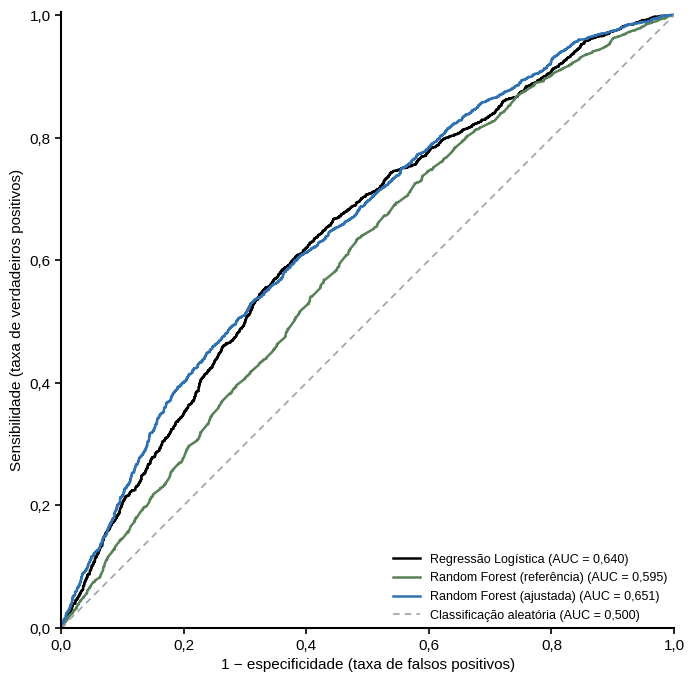

Figura X. Curvas ROC dos modelos no conjunto de teste temporal (2026)
Fonte: Resultados originais da pesquisa
Nota: n = 5.628 demandas de 2026 com avaliação registrada


In [ ]:
ESTILOS = [(PRETO, '-'), (VERDE, '-'), (AZUL_ESCURO, '-')]

fig, ax = plt.subplots(figsize=(10, 8))

for (nome, r), (cor, ls) in zip(MODELOS_FINAIS.items(), ESTILOS):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    auc = roc_auc_score(y_test, r['y_prob'])
    ax.plot(fpr, tpr, color=cor, linestyle=ls, linewidth=1.8,
            label=f'{nome} (AUC = {br(auc, 3)})')

ax.plot([0, 1], [0, 1], color='#9AA4AE', linestyle=(0, (4, 3)), linewidth=1.2,
        label='Classificação aleatória (AUC = 0,500)')

ax.set_xlim(0, 1); ax.set_ylim(0, 1.005)
ax.set_xlabel('1 − especificidade (taxa de falsos positivos)')
ax.set_ylabel('Sensibilidade (taxa de verdadeiros positivos)')
for eixo in (ax.xaxis, ax.yaxis):
    eixo.set_major_formatter(mticker.FuncFormatter(lambda v, _: br(v, 1)))
ax.tick_params(colors=PRETO, width=1.2, length=4)
for lado in ('left', 'bottom'):
    ax.spines[lado].set_linewidth(1.5)
ax.set_aspect('equal')
ax.legend(loc='lower right', frameon=False, fontsize=9,
          handlelength=2.2, borderpad=0, labelspacing=0.55)

plt.savefig('fig_curva_roc.png')
plt.show()

print(f'Figura X. Curvas ROC dos modelos no conjunto de teste temporal ({ANO_TESTE})')
print('Fonte: Resultados originais da pesquisa')
print(f'Nota: n = {br(len(y_test))} demandas de {ANO_TESTE} com avaliação registrada')

## 14. Matrizes de confusão

Os percentuais são calculados **dentro de cada classe observada** (por linha).
Assim a diagonal se lê diretamente: a célula inferior direita é a sensibilidade, a
superior esquerda é a especificidade. Normalizados pelo total, os quatro valores
somariam 100% e nada diriam sobre o desempenho por classe.

Comparam-se aqui apenas os dois modelos finais; a random forest de sem parâmetro foi
superada pela ajustada.

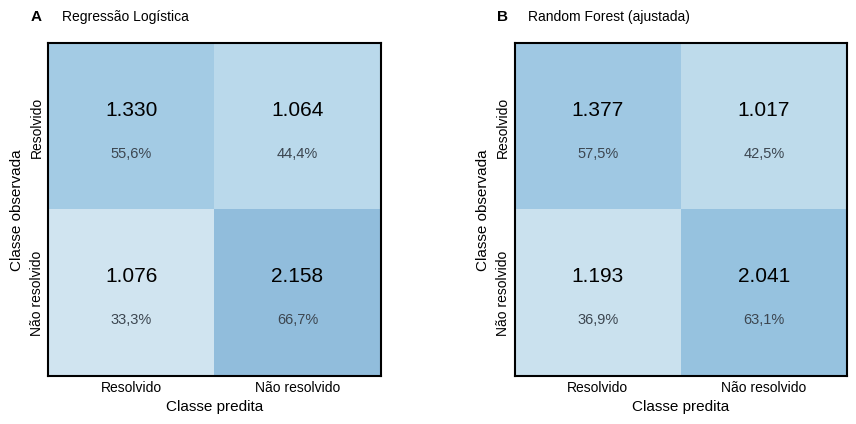

Figura X. Matrizes de confusão no conjunto de teste temporal (2026)
Fonte: Resultados originais da pesquisa
Nota: n = 5.628 demandas de 2026; limiar de 0,50; percentuais calculados dentro de cada classe observada


In [ ]:
MATRIZES = {'Regressão Logística': final['Regressão Logística'],
            'Random Forest (ajustada)': final['Random Forest']}
CLASSES = ['Resolvido', 'Não resolvido']

fig, eixos = plt.subplots(1, len(MATRIZES), figsize=(4.6 * len(MATRIZES), 4.3))

for ax, (nome, r), letra in zip(np.atleast_1d(eixos), MATRIZES.items(), 'AB'):
    yhat = (r['y_prob'] >= CUTOFF).astype(int)
    cm = confusion_matrix(y_test, yhat)
    pct = cm / cm.sum(axis=1, keepdims=True) * 100

    ax.imshow(pct, cmap='Blues', vmin=0, vmax=100, alpha=0.55)

    for i in range(2):
        for j in range(2):
            ax.text(j, i - 0.10, br(cm[i, j]), ha='center', va='center',
                    fontsize=15, color=PRETO)
            ax.text(j, i + 0.16, f'{br(pct[i, j], 1)}%', ha='center',
                    va='center', fontsize=10.5, color='#3C4650')

    ax.set_xticks([0, 1]); ax.set_xticklabels(CLASSES, fontsize=10)
    ax.set_yticks([0, 1]); ax.set_yticklabels(CLASSES, fontsize=10,
                                              rotation=90, va='center')
    ax.set_xlabel('Classe predita'); ax.set_ylabel('Classe observada')
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(True); s.set_linewidth(1.5); s.set_color(PRETO)
    ax.text(-0.02, 1.06, letra, transform=ax.transAxes, fontsize=11,
            fontweight='bold', ha='right', va='bottom')
    ax.text(0.04, 1.06, nome, transform=ax.transAxes, fontsize=10,
            ha='left', va='bottom')

plt.tight_layout(w_pad=3.0)
plt.savefig('fig_matriz_confusao.png')
plt.show()

print(f'Figura X. Matrizes de confusão no conjunto de teste temporal ({ANO_TESTE})')
print('Fonte: Resultados originais da pesquisa')
print(f'Nota: n = {br(len(y_test))} demandas de {ANO_TESTE}; limiar de {br(CUTOFF, 2)}; '
      f'percentuais calculados dentro de cada classe observada')

## 15. Interpretação da regressão logística


**Como ler:**

- **Pseudo-R² de McFadden** não se interpreta como o R² da regressão linear.
  Valores entre 0,02 e 0,20 representam ajuste razoável em dados administrativos.
- **Teste LR** compara o modelo com o modelo nulo (só intercepto). É o teste de
  significância global, equivalente ao teste F da regressão linear.
- **OR acima de 1** aumenta a chance de não resolução em relação à categoria de
  referência da variável; **abaixo de 1**, reduz.

In [ ]:
# Colunas com dependência linear exata em relação às demais (posto 88 de 90).
# Removidas só do ajuste inferencial — o X_train do scikit-learn fica intacto.
COLS_DEPENDENTES = [
    'Motivo 3_Doença ou Lesão Preexistente, CPT e Agravo',
    'TIPO_DE_PLANO_CONTRATADO_NAO INFORMADO',
]

D = sm.add_constant(X_train.drop(columns=COLS_DEPENDENTES), has_constant='add')
assert np.linalg.matrix_rank(D.to_numpy(float)) == D.shape[1], \
    'ainda há dependência linear na matriz de delineamento'

logit = sm.Logit(y_train, D).fit(disp=0, maxiter=200)

print('═' * 68)
print('AJUSTE GLOBAL — regressão logística')
print('═' * 68)
print(f'Observações                   : {br(int(logit.nobs))}')
print(f'Log-verossimilhança do modelo : {logit.llf:14.2f}')
print(f'Log-verossimilhança do nulo   : {logit.llnull:14.2f}')
print(f'Estatística LR (χ²)           : {logit.llr:14.2f}   gl = {int(logit.df_model)}')
print(f'p-valor do teste LR           : {logit.llr_pvalue:14.3g}')
print(f'Pseudo-R² de McFadden         : {logit.prsquared:14.4f}')
print(f'AIC / BIC                     : {logit.aic:12.1f} / {logit.bic:.1f}')

ic = logit.conf_int()
coeficientes = pd.DataFrame({
    'Coeficiente': logit.params, 'Erro-padrão': logit.bse,
    'z': logit.tvalues, 'p-valor': logit.pvalues,
    'OR': np.exp(logit.params),
    'IC 2,5%': np.exp(ic[0]), 'IC 97,5%': np.exp(ic[1]),
})
coeficientes.index = coeficientes.index.map(lambda n: rotulo_dummy(n, largura=999))

termos = coeficientes.drop(index='const', errors='ignore')
sig = termos[termos['p-valor'] < 0.05]
sig = sig.sort_values('z', key=lambda s: s.abs(), ascending=False)

print(f'\nTermos significativos a 5%: {len(sig)} de {len(termos)}')
print('\nOs 15 maiores em valor absoluto de z:')
print(sig.head(15).round(4).to_string())

coeficientes.round(6).to_excel('tabela_coeficientes_logistica.xlsx')
termos.round(6).to_excel('tabela_coeficientes_logistica.xlsx')

════════════════════════════════════════════════════════════════════
AJUSTE GLOBAL — regressão logística
════════════════════════════════════════════════════════════════════
Observações                   : 62.931
Log-verossimilhança do modelo :      -41620.58
Log-verossimilhança do nulo   :      -43583.47
Estatística LR (χ²)           :        3925.79   gl = 87
p-valor do teste LR           :              0
Pseudo-R² de McFadden         :         0.0450
AIC / BIC                     :      83417.2 / 84213.5

Termos significativos a 5%: 33 de 87

Os 15 maiores em valor absoluto de z:
                                                         Coeficiente  Erro-padrão        z  p-valor      OR  IC 2,5%  IC 97,5%
IGR médio dos 3 meses anteriores                              0.2407       0.0097  24.7406   0.0000  1.2721   1.2481    1.2966
Motivo da demanda: Prazos Máximos para Atendimento           -0.9672       0.0760 -12.7261   0.0000  0.3801   0.3275    0.4412
Motivo da demanda: Reajuste p

## 16. Importância das variáveis na random forest

O atributo `feature_importances_` traz a importância **por dummy**. Como uma
variável categórica ocupa várias colunas, as importâncias do bloco são somadas
para obter a importância da variável. A soma total é 1, o que permite ler
diretamente como percentual.

In [ ]:
rf = melhores_modelos['Random Forest']
imp_dummy = pd.Series(rf.feature_importances_, index=X_train.columns,
                      name='Importância').sort_values(ascending=False)

imp_var = pd.DataFrame([
    {'Variável': ROTULOS.get(v, v),
     'Importância': imp_dummy[cs].sum(),
     '%': imp_dummy[cs].sum() * 100,
     'Dummies': len(cs),
     'Média por dummy': imp_dummy[cs].sum() / len(cs)}
    for v, cs in blocos.items()
]).sort_values('Importância', ascending=False).reset_index(drop=True)

print('IMPORTÂNCIA POR VARIÁVEL')
print(imp_var.round(5).to_string(index=False))
print(f"\nSoma das importâncias: {br(imp_var['Importância'].sum(), 4)}")

print('\nAs 20 categorias individuais mais importantes:')
print(imp_dummy.head(20).round(5).to_string())

imp_var.to_excel('tabela_importancia_variaveis.xlsx', index=False)
imp_dummy.to_excel('tabela_importancia_dummies.xlsx')

IMPORTÂNCIA POR VARIÁVEL
                        Variável  Importância        %  Dummies  Média por dummy
               Motivo da demanda      0.26799 26.79879       19          0.01410
IGR médio dos 3 meses anteriores      0.24004 24.00445        1          0.24004
          Estado do beneficiário      0.12968 12.96840       26          0.00499
               Mês de referência      0.10054 10.05386       11          0.00914
                    Faixa etária      0.07610  7.61012        9          0.00846
        Tipo de plano contratado      0.03899  3.89895        3          0.01300
         Modalidade da operadora      0.03503  3.50261        4          0.00876
      Forma de contato com a ANS      0.03154  3.15436        2          0.01577
                 Natureza da NIP      0.02917  2.91675        1          0.02917
  Tipos de cobertura contratados      0.02237  2.23724       10          0.00224
                            Sexo      0.02069  2.06889        1          0.02069
   

### 16.1 Figura — importância por variável e por categoria

Painel A agrega por variável; painel B destaca as categorias individuais mais
importantes. Os dois são necessários: o primeiro responde qual variável, o
segundo qual rótulo dentro dela.

Nenhum dos dois indica **direção**, importância mede o quanto o modelo usa a
informação, não se ela aumenta ou reduz a chance de não resolução. A direção vem
das razões de chance da seção 15 e da tabela de perfil da seção 17.

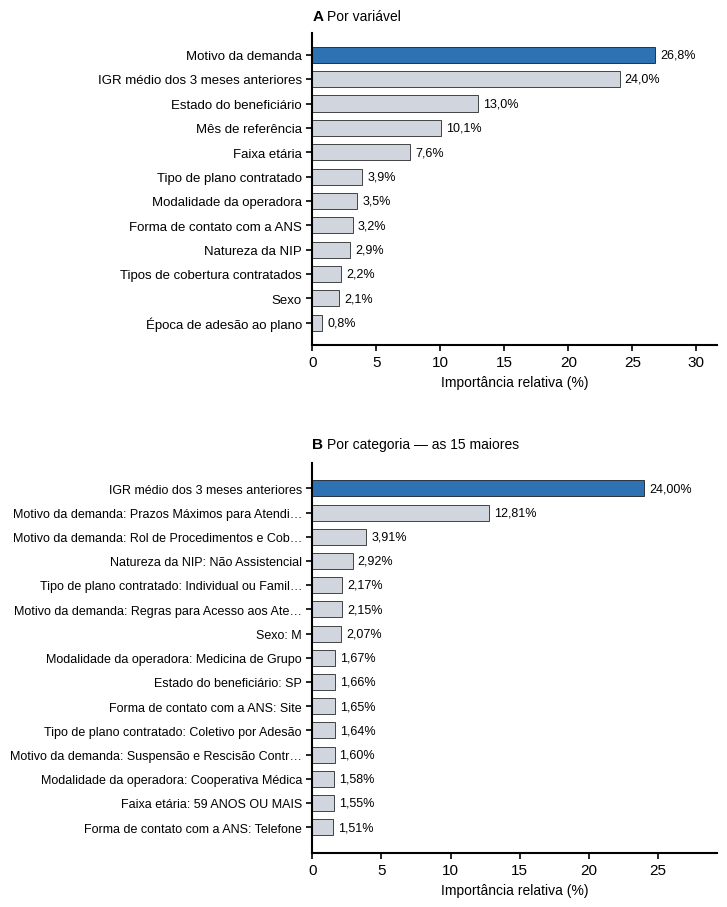

Figura X. Importância das variáveis na random forest, agregada por variável (A) e por categoria (B)
Fonte: Resultados originais da pesquisa
Nota: importância medida pela redução média de impureza; a soma das importâncias é igual a 1


In [ ]:
TOP_N = 15

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.4, 9.2),
                               gridspec_kw={'height_ratios': [len(imp_var), TOP_N]})

# ── painel A: por variável ──────────────────────────────────────────────
y = np.arange(len(imp_var))[::-1]
cores = [AZUL_ESCURO] + [AZUL_CLARO] * (len(imp_var) - 1)
ax1.barh(y, imp_var['%'], color=cores, height=0.66,
         edgecolor=PRETO, linewidth=0.5)
for yi, v in zip(y, imp_var['%']):
    ax1.text(v + imp_var['%'].max() * 0.015, yi, f'{br(v, 1)}%',
             ha='left', va='center', fontsize=9, color=PRETO)
ax1.set_yticks(y); ax1.set_yticklabels(imp_var['Variável'], fontsize=9.5)
ax1.set_xlim(0, imp_var['%'].max() * 1.18)
ax1.set_xlabel('Importância relativa (%)', fontsize=10)

# ── painel B: por categoria ─────────────────────────────────────────────
top = imp_dummy.head(TOP_N)
y2 = np.arange(TOP_N)[::-1]
cores2 = [AZUL_ESCURO] + [AZUL_CLARO] * (TOP_N - 1)
ax2.barh(y2, top.values * 100, color=cores2, height=0.66,
         edgecolor=PRETO, linewidth=0.5)
for yi, v in zip(y2, top.values * 100):
    ax2.text(v + top.max() * 100 * 0.015, yi, f'{br(v, 2)}%',
             ha='left', va='center', fontsize=9, color=PRETO)
ax2.set_yticks(y2)
ax2.set_yticklabels([rotulo_dummy(n) for n in top.index], fontsize=9)
ax2.set_xlim(0, top.max() * 100 * 1.22)
ax2.set_xlabel('Importância relativa (%)', fontsize=10)

for ax, letra, titulo in [(ax1, 'A', 'Por variável'),
                          (ax2, 'B', f'Por categoria — as {TOP_N} maiores')]:
    ax.tick_params(colors=PRETO, width=1.2, length=4)
    for lado in ('left', 'bottom'):
        ax.spines[lado].set_linewidth(1.5)
    ax.text(0.0, 1.03, letra, transform=ax.transAxes, fontsize=11,
            fontweight='bold', ha='left', va='bottom')
    ax.text(0.035, 1.03, titulo, transform=ax.transAxes, fontsize=10,
            ha='left', va='bottom')

plt.tight_layout(h_pad=3.2)
plt.savefig('fig_importancia_rf.png')
plt.show()

print('Figura X. Importância das variáveis na random forest, agregada por '
      'variável (A) e por categoria (B)')
print('Fonte: Resultados originais da pesquisa')
print('Nota: importância medida pela redução média de impureza; a soma das '
      'importâncias é igual a 1')

## 17. Perfil das categorias

Reúne, para cada categoria de cada variável, as quatro informações necessárias à
discussão:

| Coluna | O que responde |
|---|---|
| `n` e `%` | o peso da categoria na amostra |
| `Taxa não resolvido` e `Dif. p.p.` | o dado bruto, sem modelo |
| `OR` e `p-valor` | a direção do efeito, controlando as demais variáveis |
| `Importância RF` | quanto a random usa aquela categoria |

A tabela descreve o **conjunto de treino (2021–2025)**, e não 2026: é a amostra
sobre a qual os coeficientes e as importâncias foram estimados, de modo que taxa
bruta, OR e importância se referem todos à mesma população.


In [ ]:
taxa_geral = y_train.mean()
linhas_perfil = []

for var in cat_cols:
    cats_com_dummy = {c[len(var) + 1:] for c in blocos[var]}

    for cat, grupo in X_train_raw.groupby(var, observed=True):
        alvo = y_train.loc[grupo.index]
        nome = f'{var}_{cat}'
        tem = cat in cats_com_dummy                 # gerou dummy (não é referência)
        tem_coef = nome in logit.params.index       # sobreviveu ao ajuste inferencial

        if not tem:
            obs = 'referência'
        elif not tem_coef:
            obs = 'removida (colinear)'
        else:
            obs = ''

        linhas_perfil.append({
            'Variável': ROTULOS.get(var, var),
            'Categoria': cat,
            'n': len(grupo),
            '% da amostra': len(grupo) / len(X_train_raw) * 100,
            'Taxa não resolvido': alvo.mean() * 100,
            'Dif. p.p.': (alvo.mean() - taxa_geral) * 100,
            'Importância RF': imp_dummy.get(nome, np.nan) if tem else np.nan,
            'OR': np.exp(logit.params[nome]) if tem_coef else np.nan,
            'p-valor': logit.pvalues[nome] if tem_coef else np.nan,
            'Observação': obs,
        })

perfil = (pd.DataFrame(linhas_perfil)
          .sort_values(['Variável', 'Importância RF'],
                       ascending=[True, False], na_position='last'))

pd.set_option('display.width', 200)
for var in perfil['Variável'].unique():
    bloco = perfil[perfil['Variável'] == var].drop(columns='Variável')
    print(f'\n── {var} ' + '─' * max(4, 58 - len(var)))
    print(bloco.round(4).to_string(index=False))

print(f'\nTaxa geral de não resolução no treino: {br(taxa_geral * 100, 2)}%')
perfil.to_excel('tabela_perfil_categorias.xlsx', index=False)


── Estado do beneficiário ────────────────────────────────────
Categoria     n  % da amostra  Taxa não resolvido  Dif. p.p.  Importância RF     OR  p-valor Observação
       SP 21285       33.8228             44.9753    -3.3109          0.0166 0.9715   0.8010           
       BA  5381        8.5506             44.5270    -3.7592          0.0120 0.8885   0.3129           
       MG  4270        6.7852             50.7260     2.4398          0.0101 1.0393   0.7421           
       RJ  5884        9.3499             48.9633     0.6771          0.0095 1.0136   0.9071           
       AM  1303        2.0705             59.8619    11.5756          0.0088 1.4877   0.0018           
       RR   835        1.3269             65.3892    17.1030          0.0085 1.8220   0.0000           
       PE  3135        4.9816             49.7927     1.5064          0.0069 0.9848   0.8976           
       PR  2053        3.2623             41.9386    -6.3476          0.0068 0.8396   0.1547           


## 18. Escoragem de 2026 e exportação

O modelo com maior AUC no teste de 2026 é aplicado às demandas de 2026 **ainda sem
avaliação**. Duas colunas são acrescentadas à base completa:

- `PROB_NAO_RESOLVIDO` | probabilidade estimada, entre 0 e 1;
- `CLASSE_PREDITA` | classificação binária ao limiar adotado.

As linhas de outros anos, e as de 2026 que já têm avaliação, permanecem com valor
ausente nessas colunas. A coluna `ORIGEM_CLASSE` torna a distinção explícita no
painel: `observada` onde o beneficiário respondeu, `estimada` onde a probabilidade
foi calculada pelo modelo. As demandas de 2026 já avaliadas ficam marcadas como
`observada`, elas serviram de teste e **não são reescoradas**, pois nelas o
desfecho é conhecido.

In [ ]:
NOME_MODELO_FINAL = metricas_df['AUC-ROC'].idxmax()
modelo_final = MODELOS_FINAIS[NOME_MODELO_FINAL]['modelo']

print(f'Modelo selecionado: {NOME_MODELO_FINAL}')
print(f'AUC no teste ({ANO_TESTE}): {br(metricas_df.loc[NOME_MODELO_FINAL, "AUC-ROC"], 4)}\n')

prob_2026 = modelo_final.predict_proba(X_2026)[:, 1]

df_saida = df.copy()
df_saida['PROB_NAO_RESOLVIDO'] = np.nan

df_saida['CLASSE_PREDITA'] = pd.Series(pd.NA, index=df_saida.index, dtype='Int64')
df_saida['ORIGEM_CLASSE'] = np.where(df_saida[TARGET].notna(), 'observada', 'sem informação')

df_saida.loc[X_2026.index, 'PROB_NAO_RESOLVIDO'] = prob_2026
df_saida.loc[X_2026.index, 'CLASSE_PREDITA'] = (prob_2026 >= CUTOFF).astype(int)
df_saida.loc[X_2026.index, 'ORIGEM_CLASSE'] = 'estimada'


print(f'Escoradas: {br(len(X_2026))} demandas de {ANO_TESTE} sem avaliação')
print(f'Mantidas como observadas (usadas no teste): {br(len(y_test))}')
print(f'Preditas como não resolvidas: '
      f'{br((prob_2026 >= CUTOFF).sum())} '
      f'({br((prob_2026 >= CUTOFF).mean() * 100, 1)}%)\n')

print('Distribuição das probabilidades estimadas:')
print(pd.Series(prob_2026).describe().round(4).to_string())

print('\nComposição da base de saída:')
print(df_saida['ORIGEM_CLASSE'].value_counts().to_string())

Modelo selecionado: Random Forest (ajustada)
AUC no teste (2026): 0,6508

Escoradas: 10.528 demandas de 2026 sem avaliação
Mantidas como observadas (usadas no teste): 5.628
Preditas como não resolvidas: 5.451 (51,8%)

Distribuição das probabilidades estimadas:
count    10528.0000
mean         0.5006
std          0.1145
min          0.1710
25%          0.4304
50%          0.5059
75%          0.5849
max          0.7976

Composição da base de saída:
ORIGEM_CLASSE
sem informação    104709
observada          68559
estimada           10528


In [ ]:
df_saida.head()

,NUMERO_DA_DEMANDA,ABERTURA_DA_DEMANDA,ANO_DE_REFERENCIA,MES_DE_REFERENCIA,FORMA_DE_CONTATO_COM_A_ANS,REGISTRO_OPERADORA,NOME_OPERADORA,MODALIDADE_DA_OPERADORA,TIPO_DE_PLANO_CONTRATADO,EPOCA_DE_ADESAO_AO_PLANO,...,IGR_M3,REC_M3,BEN_M3,Motivo 2,Motivo 3,classe,FAIXA_ETARIA,PROB_NAO_RESOLVIDO,CLASSE_PREDITA,ORIGEM_CLASSE
0,5235508,2021-06-29,2021,Junho,Telefone,323926,UNIMED SÃO JOÃO DEL REI - COOPERATIVA DE TRABA...,Cooperativa Médica,Individual ou Familiar,POSTERIOR A 1999,...,7.902015,1.666667,21091.666667,Cobertura,Regras para Acesso aos Atendimentos,<NA>,0 A 18 ANOS,NaN,<NA>,sem informação
1,5376511,2021-10-12,2021,Outubro,Site,311961,UNIMED DE MANAUS COOP. DO TRABALHO MÉDICO LTDA,Cooperativa Médica,Individual ou Familiar,ANTERIOR A 1999,...,98.192296,20.333333,20707.666667,Cobertura,Reembolso,1,54 A 58 ANOS,NaN,<NA>,observada
2,5215153,2021-06-11,2021,Junho,Telefone,367397,UNIMED CAMPINA GRANDE - COOPERATIVA DE TRABALH...,Cooperativa Médica,Coletivo por Adesão,POSTERIOR A 1999,...,16.125521,6.666667,41342.333333,Contratos e Regulamentos,Suspensão e Rescisão Contratuais,<NA>,44 A 48 ANOS,NaN,<NA>,sem informação
3,5456832,2021-12-09,2021,Dezembro,Site,360244,PLANO DE SAÚDE ANA COSTA LTDA.,Medicina de Grupo,Coletivo Empresarial,POSTERIOR A 1999,...,15.516072,14.333333,92377.333333,Cobertura,Prazos Máximos para Atendimento,<NA>,39 A 43 ANOS,NaN,<NA>,sem informação
4,5311765,2021-08-24,2021,Agosto,Site,348295,UNIMED SOROCABA COOPERATIVA DE TRABALHO MÉDICO,Cooperativa Médica,Coletivo Empresarial,POSTERIOR A 1999,...,6.966335,6.666667,95698.333333,Cobertura,Prazos Máximos para Atendimento,<NA>,24 A 28 ANOS,NaN,<NA>,sem informação


In [ ]:
df_saida['IGR_M3'] = df_saida['IGR_M3'].round(2)
df_saida['PROB_NAO_RESOLVIDO'] = df_saida['PROB_NAO_RESOLVIDO'].round(4)

os.makedirs(os.path.dirname(ARQ_SAIDA), exist_ok=True)
df_saida.to_csv(ARQ_SAIDA, index=False, encoding='utf-8-sig',
                sep=';', decimal=',')

print(f'Arquivo gravado: {ARQ_SAIDA}')
print(f'Dimensões: {br(len(df_saida))} linhas × {df_saida.shape[1]} colunas')

# versão em parquet preserva os tipos; o CSV acima é para o Power BI
ARQ_PARQUET = ARQ_SAIDA.replace('.csv', '.parquet')
df_saida.to_parquet(ARQ_PARQUET, index=False)
print(f'Arquivo gravado: {ARQ_PARQUET}')

Arquivo gravado: /content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC/2026_CLASSIFICACAO/df_final_com_previsoes_2026.csv
Dimensões: 183.796 linhas × 34 colunas
Arquivo gravado: /content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC/2026_CLASSIFICACAO/df_final_com_previsoes_2026.parquet


## Apêndice — ambiente de execução

Versões das bibliotecas, para reprodutibilidade.

In [ ]:
import sklearn, scipy, statsmodels, matplotlib
print(f'Python      : {sys.version.split()[0]}')
print(f'pandas      : {pd.__version__}')
print(f'numpy       : {np.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'scipy       : {scipy.__version__}')
print(f'statsmodels : {statsmodels.__version__}')
print(f'matplotlib  : {matplotlib.__version__}')
print(f'\nSemente utilizada: {SEED}')

Python      : 3.13.15
pandas      : 2.2.3
numpy       : 2.1.3
scikit-learn: 1.6.1
scipy       : 1.16.3
statsmodels : 0.15.0
matplotlib  : 3.10.0

Semente utilizada: 42


In [ ]:
# ── referência do escore de Brier ───────────────────────────────────────
# A referência é o Brier do "modelo" que atribui a prevalência a todas as
# observações. Para um conjunto com prevalência π, esse valor é π(1−π).
pi_teste = y_test.mean()
ref_brier = pi_teste * (1 - pi_teste)

print(f'Prevalência da classe positiva no teste ({ANO_TESTE}) : {br(pi_teste * 100, 2)}%')
print(f'Referência do Brier — π(1−π)            : {br(ref_brier, 4)}\n')

brier_df = pd.DataFrame({
    n: {'Brier': r['teste']['Brier'],
        'Referência π(1−π)': ref_brier,
        'Brier Skill Score': 1 - r['teste']['Brier'] / ref_brier}
    for n, r in MODELOS_FINAIS.items()}).T

print('Tabela X. Escore de Brier e ganho sobre a previsão trivial')
print(brier_df.round(4).to_string())
print('Fonte: Resultados originais da pesquisa')
print(f'Nota: n = {br(len(y_test))} demandas de {ANO_TESTE} com avaliação registrada. '
      f'A referência corresponde ao escore '
      f'obtido ao atribuir a prevalência ({br(pi_teste * 100, 2)}%) a todas as '
      f'observações. Valores positivos do Brier Skill Score indicam ganho sobre '
      f'essa previsão.')

Prevalência da classe positiva no teste (2026) : 57,46%
Referência do Brier — π(1−π)            : 0,2444

Tabela X. Escore de Brier e ganho sobre a previsão trivial
                             Brier  Referência π(1−π)  Brier Skill Score
Regressão Logística         0.2335             0.2444             0.0449
Random Forest (referência)  0.2510             0.2444            -0.0267
Random Forest (ajustada)    0.2326             0.2444             0.0482
Fonte: Resultados originais da pesquisa
Nota: n = 5.628 demandas de 2026 com avaliação registrada. A referência corresponde ao escore obtido ao atribuir a prevalência (57,46%) a todas as observações. Valores positivos do Brier Skill Score indicam ganho sobre essa previsão.
